In [1]:
import tensorflow as tf
print("=" * 50)
print("TensorFlow Version:", tf.__version__)
print("=" * 50)

# Check for GPUs
gpus = tf.config.list_physical_devices('GPU')
print("Number of GPUs Available:", len(gpus))

if gpus:
    print("✅ GPU DETECTED!")
    for gpu in gpus:
        print(f"  - {gpu}")
    
    # Get GPU details
    print("\nGPU Details:")
    print(tf.config.experimental.get_device_details(gpus[0]))
else:
    print("❌ NO GPU FOUND - Running on CPU")

# Check CUDA availability
print("\nBuilt with CUDA:", tf.test.is_built_with_cuda())

print("=" * 50)

TensorFlow Version: 2.19.0
Number of GPUs Available: 1
✅ GPU DETECTED!
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU Details:
{'compute_capability': (7, 5), 'device_name': 'Tesla T4'}

Built with CUDA: True


In [3]:
# ============================================================
# DERMATOLOGY IMAGE CLASSIFICATION PIPELINE
# CNN with Transfer Learning (MobileNetV2)
# ============================================================

# ─── 1. IMPORTS ─────────────────────────────────────────────
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore")

# ─── 2. REPRODUCIBILITY ─────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── 3. GLOBAL CONFIG ───────────────────────────────────────
CONFIG = {
    "data_dir"      : "data_proj/",      # root dataset folder
    "img_size"      : (224, 224),        # input size for MobileNetV2
    "batch_size"    : 32,
    "epochs"        : 20,
    "learning_rate" : 1e-3,
    "dropout_rate"  : 0.4,
    "train_ratio"   : 0.70,
    "val_ratio"     : 0.15,
    "test_ratio"    : 0.15,              # must sum to 1.0
    "model_path"    : "derma_model.keras",
    "num_classes"   : None,             # filled automatically
}

print("✅ Imports & config ready.")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   GPU available      : {bool(tf.config.list_physical_devices('GPU'))}")

✅ Imports & config ready.
   TensorFlow version : 2.19.0
   GPU available      : True


In [4]:
!ls

sample_data


In [14]:
from google.colab import drive
drive.mount('/content/drive')
data_path = "/content/drive/MyDrive/data_proj"
os.listdir(data_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k',
 '8. Seborrheic Keratoses and other Benign Tumors - 1.8k',
 '7. Psoriasis pictures Lichen Planus and related diseases - 2k',
 '5. Melanocytic Nevi (NV) - 7970',
 '11- Acne',
 '6. Benign Keratosis-like Lesions (BKL) 2624',
 '3. Atopic Dermatitis - 1.25k',
 '10. Warts Molluscum and other Viral Infections - 2103',
 '2. Melanoma 15.75k',
 '4. Basal Cell Carcinoma (BCC) 3323',
 '1. Eczema 1677']

In [20]:
# ============================================================
# SECTION 1 — DATA LOADING & SPLITTING
# ============================================================

def load_dataset_paths(data_dir: str) -> pd.DataFrame:
    """
    Walk through `data_dir`, collect every image path and its
    label (folder name).  Returns a shuffled DataFrame.

    Expected layout:
        data_proj/
            Eczema/          img1.jpg  img2.png ...
            Melanoma/        img1.jpg ...
            ...
    """
    data_dir = Path(data_dir)
    allowed_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    records = []
    for class_folder in sorted(data_dir.iterdir()):
        if not class_folder.is_dir():
            continue
        label = class_folder.name          # folder name  →  class label
        for img_path in class_folder.iterdir():
            if img_path.suffix.lower() in allowed_exts:
                records.append({"path": str(img_path), "label": label})

    df = pd.DataFrame(records)
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # shuffle
    return df


def split_dataset(df: pd.DataFrame, cfg: dict):
    """
    Stratified split  →  train / val / test
    Ratios come from CONFIG (70 / 15 / 15).
    """
    val_test_ratio = cfg["val_ratio"] + cfg["test_ratio"]   # 0.30

    # ── train vs (val + test) ──
    train_df, temp_df = train_test_split(
        df,
        test_size    = val_test_ratio,
        stratify     = df["label"],
        random_state = SEED,
    )

    # ── val vs test  (split the 30 % equally → 15 / 15) ──
    val_ratio_adjusted = cfg["val_ratio"] / val_test_ratio   # 0.5

    val_df, test_df = train_test_split(
        temp_df,
        test_size    = 1 - val_ratio_adjusted,
        stratify     = temp_df["label"],
        random_state = SEED,
    )

    return train_df.reset_index(drop=True), \
           val_df.reset_index(drop=True),   \
           test_df.reset_index(drop=True)


# ── Run loading & splitting ──────────────────────────────────
df = load_dataset_paths(data_path)

# Build label ↔ integer mapping (sorted for reproducibility)
class_names = sorted(df["label"].unique().tolist())
CONFIG["num_classes"] = len(class_names)
label2idx   = {name: idx for idx, name in enumerate(class_names)}
idx2label   = {idx: name for name, idx in label2idx.items()}

print(f"\n📂 Total images  : {len(df):,}")
print(f"   Classes ({CONFIG['num_classes']}) : {class_names}\n")
print("Class distribution:")
print(df["label"].value_counts().to_string())

train_df, val_df, test_df = split_dataset(df, CONFIG)

print(f"\n✅ Split complete")
print(f"   Train : {len(train_df):,} images")
print(f"   Val   : {len(val_df):,}  images")
print(f"   Test  : {len(test_df):,}  images")


📂 Total images  : 28,985
   Classes (11) : ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '11- Acne', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']

Class distribution:
label
5. Melanocytic Nevi (NV) - 7970                                     7970
4. Basal Cell Carcinoma (BCC) 3323                                  3323
2. Melanoma 15.75k                                                  3140
10. Warts Molluscum and other Viral Infections - 2103               2103
6. Benign Keratosis-like Lesions (BKL) 2624                         2079
7. Psoriasis pictures Lichen Planus and related diseases - 2k       2055
8. Seborrheic Keratoses and other Beni

In [21]:
# ============================================================
# SECTION 2 — DATASET (tf.data) PIPELINE
# ============================================================

IMG_H, IMG_W = CONFIG["img_size"]
BATCH        = CONFIG["batch_size"]
AUTOTUNE     = tf.data.AUTOTUNE


# ── 2.1  Augmentation layer (train only) ────────────────────
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),         # ±15 %  of 360°
    layers.RandomZoom(0.15),             # ±15 % zoom
    layers.RandomContrast(0.10),         # slight contrast jitter
], name="augmentation")


# ── 2.2  Helper functions ────────────────────────────────────
def parse_image(path: str, label: int) -> tuple:
    """Load → decode → resize → normalise to [0, 1]."""
    raw   = tf.io.read_file(path)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_H, IMG_W])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def df_to_dataset(dataframe: pd.DataFrame,
                  augment: bool = False,
                  shuffle: bool = False) -> tf.data.Dataset:
    """
    Convert a Pandas DataFrame (columns: path, label) to
    a batched, prefetched tf.data.Dataset.
    """
    paths  = dataframe["path"].values
    labels = dataframe["label"].map(label2idx).values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)

    if augment:
        # augmentation applied INSIDE the pipeline (on GPU if available)
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE,
        )

    ds = (ds
          .batch(BATCH)
          .prefetch(AUTOTUNE))

    return ds


# ── Build the three datasets ─────────────────────────────────
train_ds = df_to_dataset(train_df, augment=True,  shuffle=True)
val_ds   = df_to_dataset(val_df,   augment=False, shuffle=False)
test_ds  = df_to_dataset(test_df,  augment=False, shuffle=False)

print("✅ tf.data pipelines ready")
print(f"   Train batches : {len(train_ds)}")
print(f"   Val   batches : {len(val_ds)}")
print(f"   Test  batches : {len(test_ds)}")

✅ tf.data pipelines ready
   Train batches : 635
   Val   batches : 136
   Test  batches : 136


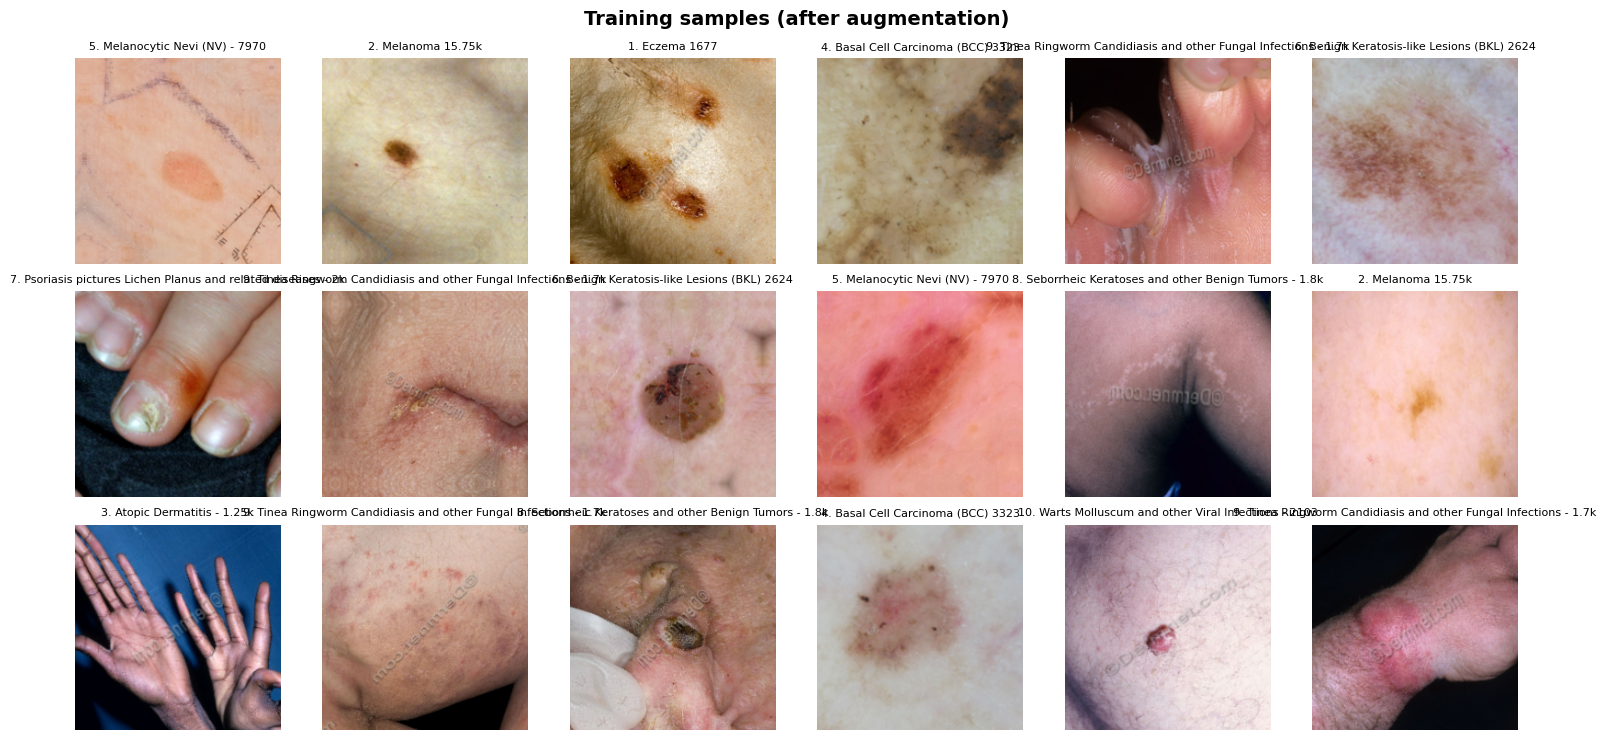

In [22]:
# ============================================================
# SECTION 3 — QUICK VISUAL CHECK (sample grid)
# ============================================================

def show_sample_grid(dataset: tf.data.Dataset,
                     class_names: list,
                     rows: int = 3,
                     cols: int = 6,
                     title: str = "Sample images"):
    images, labels = next(iter(dataset))
    images = images.numpy()
    labels = labels.numpy()

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    for ax, img, lbl in zip(axes.flat, images, labels):
        ax.imshow(img)
        ax.set_title(class_names[lbl], fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_sample_grid(train_ds, class_names, title="Training samples (after augmentation)")

In [23]:
# ============================================================
# SECTION 4 — MODEL DEFINITION  (Transfer Learning)
# ============================================================

def build_model(num_classes: int,
                img_size: tuple,
                learning_rate: float,
                dropout_rate: float) -> tf.keras.Model:
    """
    MobileNetV2 backbone (ImageNet weights, frozen initially)
    + lightweight classification head.

    Architecture
    ────────────
    Input (224×224×3)
      ↓  MobileNetV2  [frozen]
      ↓  GlobalAveragePooling2D
      ↓  BatchNormalization
      ↓  Dense(256, relu)
      ↓  Dropout(dropout_rate)
      ↓  Dense(num_classes, softmax)
    """
    # ── Base model ───────────────────────────────────────────
    base_model = MobileNetV2(
        input_shape = (*img_size, 3),
        include_top = False,           # remove original classifier
        weights     = "imagenet",
    )
    base_model.trainable = False       # freeze all base layers

    # ── Input ────────────────────────────────────────────────
    inputs = tf.keras.Input(shape=(*img_size, 3), name="input_image")

    # NOTE: MobileNetV2 expects pixel values in [-1, 1].
    #       Our pipeline normalises to [0,1], so we rescale here.
    x = tf.keras.applications.mobilenet_v2.preprocess_input(
        inputs * 255.0              # undo [0,1] → pass raw [0,255] to preprocessor
    )

    # ── Feature extraction ───────────────────────────────────
    x = base_model(x, training=False)  # training=False → BN stays in inference mode

    # ── Classification head ──────────────────────────────────
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="bn")(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = tf.keras.Model(inputs, outputs, name="DermaNet")

    # ── Compile ──────────────────────────────────────────────
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss      = "sparse_categorical_crossentropy",   # labels are integers
        metrics   = ["accuracy"],
    )

    return model, base_model


model, base_model = build_model(
    num_classes   = CONFIG["num_classes"],
    img_size      = CONFIG["img_size"],
    learning_rate = CONFIG["learning_rate"],
    dropout_rate  = CONFIG["dropout_rate"],
)

model.summary()
print(f"\n🔒 Trainable params  : {model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DermaNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,867 (9.89 MB)

 Trainable params: 333,323 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


🔒 Trainable params  : 2,593,867


In [24]:
# ============================================================
# SECTION 5 — PHASE 1 TRAINING  (frozen backbone)
# ============================================================

# ── Callbacks ───────────────────────────────────────────────
cb_early_stop = callbacks.EarlyStopping(
    monitor              = "val_accuracy",
    patience             = 5,
    restore_best_weights = True,
    verbose              = 1,
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor  = "val_loss",
    factor   = 0.3,
    patience = 3,
    min_lr   = 1e-7,
    verbose  = 1,
)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath             = "best_model_phase1.keras",
    monitor              = "val_accuracy",
    save_best_only       = True,
    verbose              = 1,
)

# ── Train Phase 1 ───────────────────────────────────────────
print("\n🚀 Phase 1 — training classification head (frozen backbone) …\n")

history_phase1 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = CONFIG["epochs"],
    callbacks       = [cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose         = 1,
)

print("\n✅ Phase 1 complete.")


🚀 Phase 1 — training classification head (frozen backbone) …

Epoch 1/20
635/635 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5036 - loss: 1.5914
Epoch 1: val_accuracy improved from None to 0.62833, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
635/635 ━━━━━━━━━━━━━━━━━━━━ 4347s 7s/step - accuracy: 0.5587 - loss: 1.3205 - val_accuracy: 0.6283 - val_loss: 0.9755 - learning_rate: 0.0010
Epoch 2/20
634/635 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.6241 - loss: 1.0085
Epoch 2: val_accuracy improved from 0.62833 to 0.63937, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
635/635 ━━━━━━━━━━━━━━━━━━━━ 340s 535ms/step - accuracy: 0.6329 - loss: 0.9950 - val_accuracy: 0.6394 - val_loss: 0.9427 - learning_rate: 0.0010
Epoch 3/20
634/635 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.6606 - loss: 0.9286
Epoch 3: val_accuracy improved from 0.63937 to 0.66168, saving model to best_mode

In [25]:
# ============================================================
# SECTION 6 — PHASE 2 TRAINING  (fine-tuning — unfreeze top layers)
# ============================================================

def unfreeze_top_layers(base_model, num_layers_to_unfreeze: int = 30):
    """
    Unfreeze the last `num_layers_to_unfreeze` layers of the
    backbone for fine-tuning with a very small learning rate.
    """
    base_model.trainable = True
    total_layers = len(base_model.layers)
    freeze_until = total_layers - num_layers_to_unfreeze

    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False

    trainable = sum(1 for l in base_model.layers if l.trainable)
    print(f"   Total base layers   : {total_layers}")
    print(f"   Frozen layers       : {freeze_until}")
    print(f"   Unfrozen (trainable): {trainable}")


unfreeze_top_layers(base_model, num_layers_to_unfreeze=30)

# Recompile with a lower learning rate
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = "sparse_categorical_crossentropy",
    metrics   = ["accuracy"],
)

cb_checkpoint_ft = callbacks.ModelCheckpoint(
    filepath       = CONFIG["model_path"],   # final best model
    monitor        = "val_accuracy",
    save_best_only = True,
    verbose        = 1,
)

print("\n🚀 Phase 2 — fine-tuning top layers …\n")

history_phase2 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 10,
    callbacks       = [cb_early_stop, cb_reduce_lr, cb_checkpoint_ft],
    verbose         = 1,
)

print("\n✅ Phase 2 complete. Best model saved →", CONFIG["model_path"])

   Total base layers   : 154
   Frozen layers       : 124
   Unfrozen (trainable): 30

🚀 Phase 2 — fine-tuning top layers …

Epoch 1/10
635/635 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.6003 - loss: 1.1139
Epoch 1: val_accuracy improved from None to 0.67778, saving model to derma_model.keras

Epoch 1: finished saving model to derma_model.keras
635/635 ━━━━━━━━━━━━━━━━━━━━ 374s 557ms/step - accuracy: 0.6242 - loss: 1.0399 - val_accuracy: 0.6778 - val_loss: 1.2155 - learning_rate: 1.0000e-05
Epoch 2/10
634/635 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.6528 - loss: 0.9392
Epoch 2: val_accuracy improved from 0.67778 to 0.68882, saving model to derma_model.keras

Epoch 2: finished saving model to derma_model.keras
635/635 ━━━━━━━━━━━━━━━━━━━━ 356s 535ms/step - accuracy: 0.6681 - loss: 0.9115 - val_accuracy: 0.6888 - val_loss: 0.9826 - learning_rate: 1.0000e-05
Epoch 3/10
634/635 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.6864 - loss: 0.8564
Epoch 3: ReduceLROnPlateau red

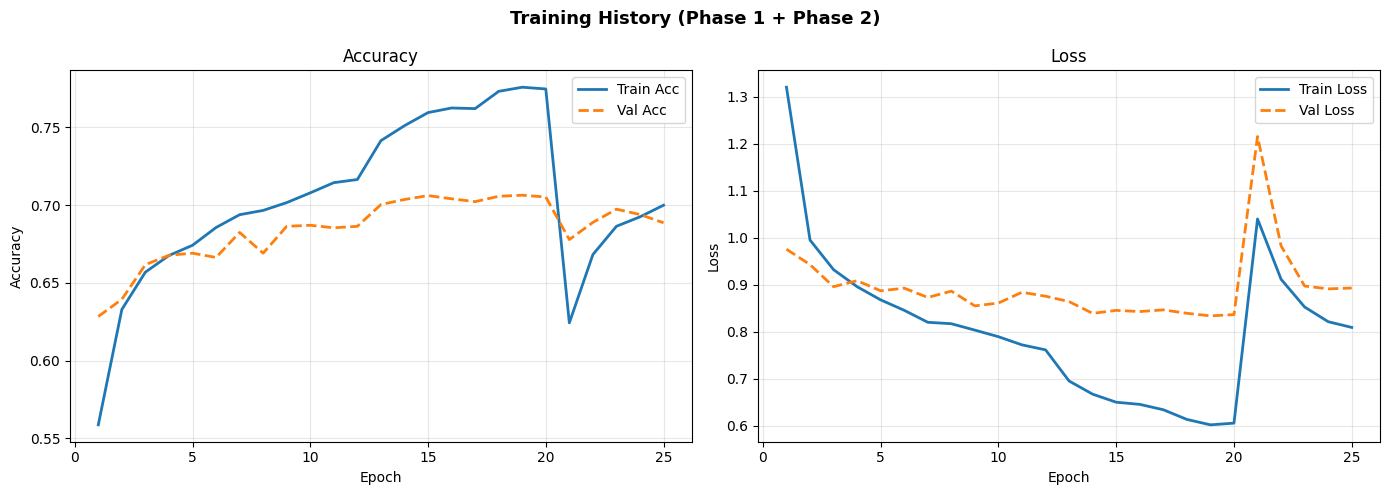

📊 Curves saved → training_curves.png


In [26]:
# ============================================================
# SECTION 7 — TRAINING CURVES
# ============================================================

def merge_histories(*histories):
    """Concatenate multiple Keras history objects."""
    merged = {}
    for h in histories:
        for key, vals in h.history.items():
            merged.setdefault(key, []).extend(vals)
    return merged


def plot_history(history_dict: dict):
    """Plot accuracy and loss curves."""
    epochs_range = range(1, len(history_dict["accuracy"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training History (Phase 1 + Phase 2)", fontsize=13, fontweight="bold")

    # ── Accuracy ──
    axes[0].plot(epochs_range, history_dict["accuracy"],     label="Train Acc",  lw=2)
    axes[0].plot(epochs_range, history_dict["val_accuracy"], label="Val Acc",    lw=2, linestyle="--")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Loss ──
    axes[1].plot(epochs_range, history_dict["loss"],     label="Train Loss", lw=2)
    axes[1].plot(epochs_range, history_dict["val_loss"], label="Val Loss",   lw=2, linestyle="--")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("📊 Curves saved → training_curves.png")


merged = merge_histories(history_phase1, history_phase2)
plot_history(merged)

✅ Best model loaded from 'derma_model.keras'

────────────────────────────────────────
  Validation  →  loss: 0.8971   accuracy: 0.6973
  Test        →  loss: 0.8612   accuracy: 0.6966
────────────────────────────────────────

📋 Classification Report:

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677     0.3901    0.5936    0.4708       251
           10. Warts Molluscum and other Viral Infections - 2103     0.5688    0.4857    0.5240       315
                                                        11- Acne     0.8034    0.8618    0.8316       275
                                              2. Melanoma 15.75k     0.8272    0.7622    0.7934       471
                                    3. Atopic Dermatitis - 1.25k     0.4630    0.3968    0.4274       189
                              4. Basal Cell Carcinoma (BCC) 3323     0.7886    0.8297    0.8086       499
    

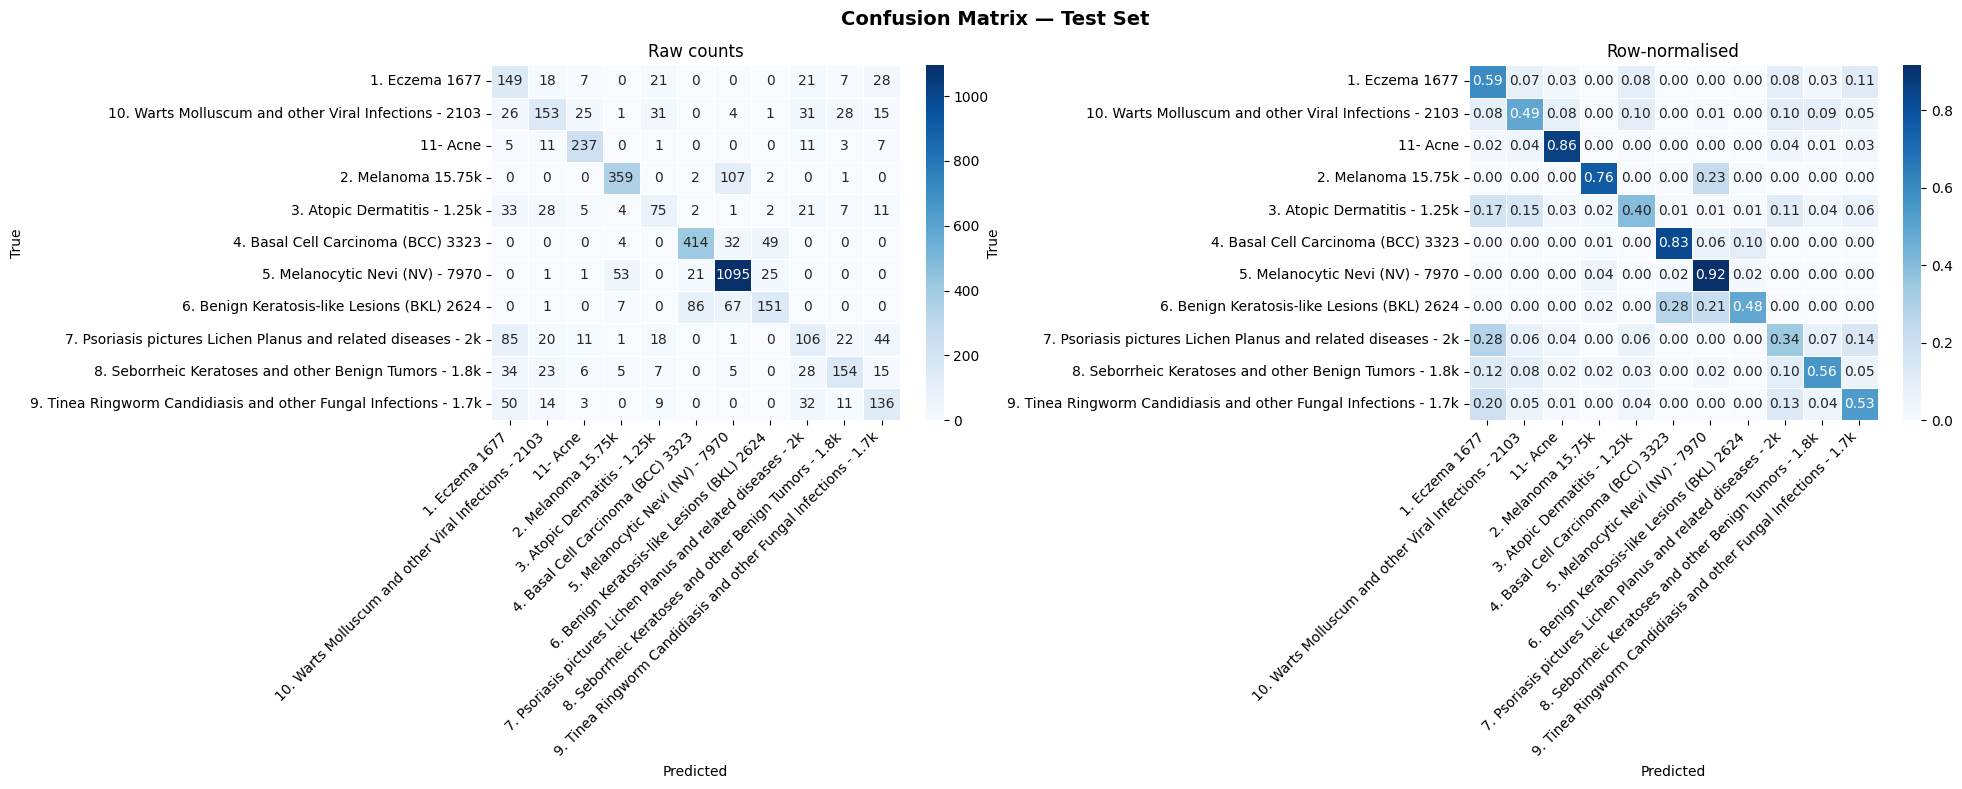

📊 Confusion matrix saved → confusion_matrix.png


In [27]:
# ============================================================
# SECTION 8 — EVALUATION
# ============================================================

# ── 8.1  Load best saved model ───────────────────────────────
best_model = tf.keras.models.load_model(CONFIG["model_path"])
print(f"✅ Best model loaded from '{CONFIG['model_path']}'")


# ── 8.2  Val & test metrics ──────────────────────────────────
val_loss,  val_acc  = best_model.evaluate(val_ds,  verbose=0)
test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)

print(f"\n{'─'*40}")
print(f"  Validation  →  loss: {val_loss:.4f}   accuracy: {val_acc:.4f}")
print(f"  Test        →  loss: {test_loss:.4f}   accuracy: {test_acc:.4f}")
print(f"{'─'*40}")


# ── 8.3  Predictions on test set ─────────────────────────────
def get_predictions(model, dataset):
    """Return ground-truth labels and predicted class indices."""
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)


y_true, y_pred = get_predictions(best_model, test_ds)


# ── 8.4  Classification report ───────────────────────────────
print("\n📋 Classification Report:\n")
print(classification_report(y_true, y_pred,
                             target_names=class_names,
                             digits=4))


# ── 8.5  Confusion matrix ────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalised

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")

    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ["d", ".2f"],
        ["Raw counts", "Row-normalised"],
    ):
        sns.heatmap(
            data,
            annot      = True,
            fmt        = fmt,
            cmap       = "Blues",
            xticklabels= class_names,
            yticklabels= class_names,
            linewidths = 0.5,
            ax         = ax,
        )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_ylabel("True",      fontsize=10)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()
    print("📊 Confusion matrix saved → confusion_matrix.png")


plot_confusion_matrix(y_true, y_pred, class_names)

In [28]:
# ============================================================
# SECTION 9 — SAVING & LOADING
# ============================================================

# ── Save ─────────────────────────────────────────────────────
best_model.save(CONFIG["model_path"])          # .keras  (recommended)
best_model.save("derma_model.h5")             # legacy  .h5
print(f"💾 Model saved as '{CONFIG['model_path']}' and 'derma_model.h5'")

# ── Load (demo) ──────────────────────────────────────────────
loaded_model = tf.keras.models.load_model(CONFIG["model_path"])
print(f"✅ Model loaded successfully. Input shape: {loaded_model.input_shape}")

💾 Model saved as 'derma_model.keras' and 'derma_model.h5'
✅ Model loaded successfully. Input shape: (None, 224, 224, 3)



🔍 Inference demo
   Image path   : /content/drive/MyDrive/data_proj/5. Melanocytic Nevi (NV) - 7970/ISIC_0031830.jpg
   True label   : 5. Melanocytic Nevi (NV) - 7970
   Prediction   : 5. Melanocytic Nevi (NV) - 7970  (56.5 %)
   Top-3 :
     5. Melanocytic Nevi (NV) - 7970     56.5 %
     2. Melanoma 15.75k                  43.4 %
     6. Benign Keratosis-like Lesions (BKL) 2624 0.1 %


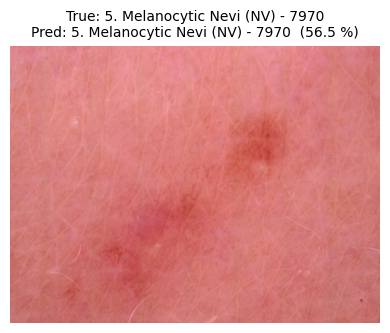

In [29]:
# ============================================================
# SECTION 10 — INFERENCE FUNCTION
# ============================================================

def predict_image(image_path: str,
                  model: tf.keras.Model = None,
                  img_size: tuple = (224, 224),
                  top_k: int = 3) -> dict:
    """
    Preprocess a single image and return the predicted class
    plus confidence (and top-k alternatives).

    Parameters
    ----------
    image_path : str   path to the image file
    model      : loaded Keras model (uses global `best_model` if None)
    img_size   : (H, W) expected by the model
    top_k      : how many top predictions to return

    Returns
    -------
    dict  {
            "disease"     : str,
            "confidence"  : float,
            "top_k"       : [{"disease": str, "confidence": float}, ...]
          }
    """
    if model is None:
        model = best_model          # fall back to global

    # ── Load & preprocess ────────────────────────────────────
    img   = load_img(image_path, target_size=img_size)
    arr   = img_to_array(img) / 255.0           # normalise to [0, 1]
    batch = np.expand_dims(arr, axis=0)         # (1, H, W, 3)

    # ── Predict ──────────────────────────────────────────────
    probs      = model.predict(batch, verbose=0)[0]     # shape (num_classes,)
    pred_idx   = int(np.argmax(probs))
    confidence = float(probs[pred_idx])

    # ── Top-k ─────────────────────────────────────────────────
    top_indices = np.argsort(probs)[::-1][:top_k]
    top_k_list  = [
        {"disease": idx2label[i], "confidence": round(float(probs[i]), 4)}
        for i in top_indices
    ]

    result = {
        "disease"    : idx2label[pred_idx],
        "confidence" : round(confidence, 4),
        "top_k"      : top_k_list,
    }
    return result


# ── Quick demo ───────────────────────────────────────────────
# Grab a random image from test_df and run inference
sample_row = test_df.sample(1, random_state=99).iloc[0]
result      = predict_image(sample_row["path"])

print("\n🔍 Inference demo")
print(f"   Image path   : {sample_row['path']}")
print(f"   True label   : {sample_row['label']}")
print(f"   Prediction   : {result['disease']}  ({result['confidence']*100:.1f} %)")
print(f"   Top-{len(result['top_k'])} :")
for item in result["top_k"]:
    print(f"     {item['disease']:35s} {item['confidence']*100:.1f} %")

# ── Visualise ────────────────────────────────────────────────
img = Image.open(sample_row["path"])
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"True: {sample_row['label']}\n"
    f"Pred: {result['disease']}  ({result['confidence']*100:.1f} %)",
    fontsize=10,
)
plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# SECTION 11 — FASTAPI ENDPOINT  (Bonus)
# ============================================================
# Run in a SEPARATE .py file or terminal, NOT inside Jupyter.
# Start server:  uvicorn app:app --reload --port 8000
# Test:          curl -X POST http://localhost:8000/predict \
#                     -F "file=@your_image.jpg"
# ============================================================

FASTAPI_CODE = '''
# app.py  ─────────────────────────────────────────────────────
import io
import numpy as np
from pathlib import Path

from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.responses import JSONResponse
import tensorflow as tf
from PIL import Image

# ── Config ───────────────────────────────────────────────────
MODEL_PATH  = "derma_model.keras"
IMG_SIZE    = (224, 224)
CLASS_NAMES = [           # must match training order  (sorted alphabetically)
    "Acne",
    "Atopic Dermatitis",
    "Basal Cell Carcinoma",
    "Benign Keratosis-like Lesions",
    "Eczema",
    "Melanocytic Nevi",
    "Melanoma",
    "Psoriasis",
    "Seborrheic Keratoses",
    "Tinea",
    "Warts",
]

# ── Load model once at startup ────────────────────────────────
app = FastAPI(
    title       = "Dermatology AI API",
    description = "CNN-based skin disease classifier",
    version     = "1.0.0",
)

model = None   # lazy-loaded

@app.on_event("startup")
def load_model():
    global model
    model = tf.keras.models.load_model(MODEL_PATH)
    print(f"✅ Model loaded from {MODEL_PATH}")


# ── Helper ────────────────────────────────────────────────────
def preprocess(image_bytes: bytes) -> np.ndarray:
    img   = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img   = img.resize(IMG_SIZE)
    arr   = np.array(img, dtype=np.float32) / 255.0
    return np.expand_dims(arr, axis=0)   # (1, H, W, 3)


# ── Endpoint ──────────────────────────────────────────────────
@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    """
    Accepts an image file and returns:
        {
            "disease"    : "Melanoma",
            "confidence" : 0.92,
            "top_3"      : [...]
        }
    """
    if not file.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="File must be an image.")

    image_bytes = await file.read()

    try:
        batch  = preprocess(image_bytes)
        probs  = model.predict(batch, verbose=0)[0]
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Prediction error: {e}")

    pred_idx   = int(np.argmax(probs))
    confidence = float(probs[pred_idx])

    top3_idx  = np.argsort(probs)[::-1][:3]
    top3      = [
        {"disease": CLASS_NAMES[i], "confidence": round(float(probs[i]), 4)}
        for i in top3_idx
    ]

    return JSONResponse({
        "disease"    : CLASS_NAMES[pred_idx],
        "confidence" : round(confidence, 4),
        "top_3"      : top3,
    })


@app.get("/health")
def health():
    return {"status": "ok", "model_loaded": model is not None}
'''

# ── Write app.py to disk ─────────────────────────────────────
with open("app.py", "w") as fh:
    fh.write(FASTAPI_CODE.strip())

print("✅ FastAPI app written → app.py")
print()
print("   To install deps:  pip install fastapi uvicorn python-multipart")
print("   To start server:  uvicorn app:app --reload --port 8000")
print("   Swagger UI:       http://localhost:8000/docs")

✅ FastAPI app written → app.py

   To install deps:  pip install fastapi uvicorn python-multipart
   To start server:  uvicorn app:app --reload --port 8000
   Swagger UI:       http://localhost:8000/docs


In [31]:
# ============================================================
# SECTION 11 — FASTAPI ENDPOINT  (Bonus)
# ============================================================
# Run in a SEPARATE .py file or terminal, NOT inside Jupyter.
# Start server:  uvicorn app:app --reload --port 8000
# Test:          curl -X POST http://localhost:8000/predict \
#                     -F "file=@your_image.jpg"
# ============================================================

FASTAPI_CODE = '''
# app.py  ─────────────────────────────────────────────────────
import io
import numpy as np
from pathlib import Path

from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.responses import JSONResponse
import tensorflow as tf
from PIL import Image

# ── Config ───────────────────────────────────────────────────
MODEL_PATH  = "derma_model.keras"
IMG_SIZE    = (224, 224)
CLASS_NAMES = [           # must match training order  (sorted alphabetically)
    "Acne",
    "Atopic Dermatitis",
    "Basal Cell Carcinoma",
    "Benign Keratosis-like Lesions",
    "Eczema",
    "Melanocytic Nevi",
    "Melanoma",
    "Psoriasis",
    "Seborrheic Keratoses",
    "Tinea",
    "Warts",
]

# ── Load model once at startup ────────────────────────────────
app = FastAPI(
    title       = "Dermatology AI API",
    description = "CNN-based skin disease classifier",
    version     = "1.0.0",
)

model = None   # lazy-loaded

@app.on_event("startup")
def load_model():
    global model
    model = tf.keras.models.load_model(MODEL_PATH)
    print(f"✅ Model loaded from {MODEL_PATH}")


# ── Helper ────────────────────────────────────────────────────
def preprocess(image_bytes: bytes) -> np.ndarray:
    img   = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img   = img.resize(IMG_SIZE)
    arr   = np.array(img, dtype=np.float32) / 255.0
    return np.expand_dims(arr, axis=0)   # (1, H, W, 3)


# ── Endpoint ──────────────────────────────────────────────────
@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    """
    Accepts an image file and returns:
        {
            "disease"    : "Melanoma",
            "confidence" : 0.92,
            "top_3"      : [...]
        }
    """
    if not file.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="File must be an image.")

    image_bytes = await file.read()

    try:
        batch  = preprocess(image_bytes)
        probs  = model.predict(batch, verbose=0)[0]
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Prediction error: {e}")

    pred_idx   = int(np.argmax(probs))
    confidence = float(probs[pred_idx])

    top3_idx  = np.argsort(probs)[::-1][:3]
    top3      = [
        {"disease": CLASS_NAMES[i], "confidence": round(float(probs[i]), 4)}
        for i in top3_idx
    ]

    return JSONResponse({
        "disease"    : CLASS_NAMES[pred_idx],
        "confidence" : round(confidence, 4),
        "top_3"      : top3,
    })


@app.get("/health")
def health():
    return {"status": "ok", "model_loaded": model is not None}
'''

# ── Write app.py to disk ─────────────────────────────────────
with open("app.py", "w") as fh:
    fh.write(FASTAPI_CODE.strip())

print("✅ FastAPI app written → app.py")
print()
print("   To install deps:  pip install fastapi uvicorn python-multipart")
print("   To start server:  uvicorn app:app --reload --port 8000")
print("   Swagger UI:       http://localhost:8000/docs")

✅ FastAPI app written → app.py

   To install deps:  pip install fastapi uvicorn python-multipart
   To start server:  uvicorn app:app --reload --port 8000
   Swagger UI:       http://localhost:8000/docs
